# Table of contents

**1. Installation & setup**
   - Install bombcell package
   - Import libraries and set up paths
   - Configure parameters for both quality metrics and ephys properties

**2. Quality metrics analysis**
   - Run bombcell quality control pipeline
   - Classify units (good/MUA/noise/non-somatic)
   - Explore quality metrics results
   - Use interactive GUI for manual validation
   - Fine-tune classification parameters

**3. Ephys properties & cell classification** 
   - Compute electrophysiological properties (firing patterns, waveform features, etc.)
   - Classify cell types (cortical: pyramidal/interneurons, striatal: MSN/FSI/UIN)
   - Generate classification plots and results

---

# 1. Installation & setup

#### Install bombcell

To install the latest stable version:
```bash
conda create -n bombcell python=3.11
conda activate bombcell
pip install uv
uv pip install bombcell # you could do `pip install .`, but uv is much quicker!
```
To install the dev version (with the latest updates): 
```bash
conda create -n bombcell python=3.11
conda activate bombcell
git clone https://github.com/Julie-Fabre/bombcell.git
cd bombcell/pyBombCell
pip install uv
uv pip install -e .
```

#### Import libraries

In [1]:
import os, sys
from pathlib import Path
from pprint import pprint 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
%load_ext autoreload
%autoreload 2

import bombcell as bc

✅ ipywidgets available - interactive GUI ready


In [2]:
# Optional

# # Add bombcell to Python path if NOT installed with pip
# # If notebook is running in bombcell repo:
# demo_dir = Path(os.getcwd())
# pyBombCell_dir = demo_dir.parent
# # Else:
# # pyBombCell_dir = "path/to/bombcell/repository/root"
# sys.path.append(str(pyBombCell_dir))

#### Define paths

In [ ]:
# Need to remove the bombcell folder in the following 4 folders from the animal GN26019 because the raw file is not preprocessed.
#ks_dir = r"Y:\GN26019\260301\coherence\session1\2026-03-01_18-27-23\kilosort4_motion_corrected"
#ks_dir = r"Y:\GN26019\260301\choices\session2\2026-03-01_15-59-22\kilosort4_motion_corrected"
#ks_dir = r"Y:\GN26019\260301\choices\session1\2026-03-01_14-41-31\kilosort4_motion_corrected"
#ks_dir = r"Y:\GN26019\260301\spontaneous\session1\2026-03-01_14-10-06\kilosort4_motion_corrected"
ks_dir = r"Y:\GN26020\260307\spontaneous\session1\2026-03-07_12-02-05\kilosort4_motion_corrected"
# Set bombcell's output directory
save_path = Path(ks_dir) / "bombcell"

print(f"Using kilosort directory: {ks_dir}")

Using kilosort directory: Y:\GN26020\260307\spontaneous\session1\2026-03-07_12-02-05\kilosort4_motion_corrected


# Section 1: Quality Metrics

In [4]:
## Provide raw and meta files
## Leave 'None' if no raw data. Ideally, your raw data is common-average-referenced and
# the channels are temporally aligned to each other (this can be done with CatGT)
#raw_file_path =  r"Y:\GN26019\260301\coherence\session1\2026-03-01_18-27-23\Record Node 101\experiment1\recording1\continuous\Acquisition_Board-100.acquisition_board\continuous.dat" #None#"/home/julie/Dropbox/Example datatsets/JF093_2023-03-09_site1/site1/2023-03-09_JF093_g0_t0_bc_decompressed.imec0.ap.bin" # ks_dir
#raw_file_path =  r"Y:\GN26019\260301\choices\session2\2026-03-01_15-59-22\Record Node 101\experiment1\recording1\continuous\Acquisition_Board-100.acquisition_board\continuous.dat"
#raw_file_path =  r"Y:\GN26019\260301\choices\session1\2026-03-01_14-41-31\Record Node 101\experiment1\recording1\continuous\Acquisition_Board-100.acquisition_board\continuous.dat"
#raw_file_path =  r"Y:\GN26019\260301\spontaneous\session1\2026-03-01_14-10-06\Record Node 101\experiment1\recording1\continuous\Acquisition_Board-100.acquisition_board\continuous.dat"
raw_file_path=Path(ks_dir) / "temp_wh.dat" 
#meta_file_path = r"Y:\GN26019\260301\coherence\session1\2026-03-01_18-27-23\Record Node 101\experiment1\recording1\structure.oebin" #None#"/home/julie/Dropbox/Example datatsets/JF093_2023-03-09_site1/site1/2023-03-09_JF093_g0_t0_bc_decompressed.imec0.ap.bin"None#"/home/julie/Dropbox/Example datatsets/JF093_2023-03-09_site1/site1/2023-03-09_JF093_g0_t0.imec0.ap.meta"
#meta_file_path = r"Y:\GN26019\260301\choices\session2\2026-03-01_15-59-22\Record Node 101\experiment1\recording1\structure.oebin"
#meta_file_path = r"Y:\GN26019\260301\choices\session1\2026-03-01_14-41-31\Record Node 101\experiment1\recording1\structure.oebin"
#meta_file_path = r"Y:\GN26019\260301\spontaneous\session1\2026-03-01_14-10-06\Record Node 101\experiment1\recording1\structure.oebin"
meta_file_path = r"Y:\GN26020\260307\spontaneous\session1\2026-03-07_12-02-05\Record Node 101\experiment1\recording1\structure.oebin"


In [ ]:
## Get default parameters - we will see later in the notebook how to assess and fine-tune these
param = bc.get_default_parameters(ks_dir, 
                                  raw_file=raw_file_path,
                                  meta_file=meta_file_path,
                                  kilosort_version=4)

print("Bombcell parameters:")
pprint(param)
param["computeDistanceMetrics"] = 0
param["computeDrift"] = 0
param["splitGoodAndMua_NonSomatic"] = 0
#  3. how quality metricsa are calculated:
# a. how refractory period window is defined
param["tauR_valuesMin"]= 0.5 / 1000  # minumum refractory period time (s), usually 0.002 s
param["tauR_valuesMax"]= 5 / 1000  # maximum refractory period time (s)
param["tauR_valuesStep"]= 0.5 / 1000  # if tauR_valuesMin and tauR_valuesMax are different, bombcell

Bombcell parameters:
{'computeDistanceMetrics': False,
 'computeDrift': False,
 'computeSpatialDecay': True,
 'computeTimeChunks': False,
 'decompress_data': False,
 'deltaTimeChunk': 360,
 'detrendForUnitMatch': False,
 'detrendWaveform': True,
 'driftBinSize': 60,
 'duplicateSpikeWindow_s': 3.4e-05,
 'ephysKilosortPath': 'Y:\\GN26020\\260307\\spontaneous\\session1\\2026-03-07_12-02-05\\kilosort4_motion_corrected',
 'ephys_meta_file': 'Y:\\GN26020\\260307\\spontaneous\\session1\\2026-03-07_12-02-05\\Record '
                    'Node 101\\experiment1\\recording1\\structure.oebin',
 'ephys_sample_rate': 30000,
 'extractRaw': True,
 'gain_to_uV': 0.1949999928474426,
 'hillOrLlobetMethod': True,
 'isoDmin': 20,
 'lratioMax': 0.3,
 'maxDrift': 100,
 'maxMainPeakToTroughRatio_nonSomatic': 0.8,
 'maxNPeaks': 2,
 'maxNTroughs': 1,
 'maxPeak1ToPeak2Ratio_nonSomatic': 3,
 'maxPercSpikesMissing': 20,
 'maxRPVviolations': 0.1,
 'maxScndPeakToTroughRatio_noise': 0.8,
 'maxSpatialDecaySlopeExp': 0

##### Optionally, customize parameters (more on this later, below)

In [ ]:
# you might to change:

# 1. classification thresholds like: 
# param["maxRPVviolations"] = 0.1

#  2. or which quality metrics are computed (by default these are not): 
param["computeDistanceMetrics"] = 0
param["computeDrift"] = 0
param["splitGoodAndMua_NonSomatic"] = 0

#  3. how quality metricsa are calculated:
# a. how refractory period window is defined
param["tauR_valuesMin"]= 0.002  # minumum refractory period time (s), usually 0.002 s 
param["tauR_valuesMax"]= 5 / 1000  # maximum refractory period time (s)
param["tauR_valuesStep"]= 0.5 / 1000  # if tauR_valuesMin and tauR_valuesMax are different, bombcell

'''
These were  suggested for neurons with bursty firing
param.tauR_valuesMin = 1.5/1000;
param.tauR_valuesMax = 2.4/1000;
param.tauR_valuesStep = 0.1/1000;

'''

# will calculate refractory period violations from param["tauR_valuesMin"] to param["tauR_valuesMax"] param["tauR_valuesStep"] 
# bins and determine the option window for each unit before calculating the violations. 
        # tauR_valuesStep
#  b. or whether the recording is split into time chunks to detemrine "good" time chunks: 
# param["computeTimeChunks"] = 0
# full list in the wiki or in the bc.get_default_parameters function

🚀 Starting BombCell quality metrics pipeline...
📁 Processing data from: Y:\GN26020\260307\spontaneous\session1\2026-03-07_12-02-05\kilosort4_motion_corrected
Results will be saved to: Y:\GN26020\260307\spontaneous\session1\2026-03-07_12-02-05\kilosort4_motion_corrected\bombcell

Loading ephys data...
Loaded ephys data: 166 units, 1,951,385 spikes

🔍 Extracting raw waveforms...


0it [00:00, ?it/s]

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:   12.7s
[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:   14.3s
[Parallel(n_jobs=-1)]: Done  17 tasks      | elapsed:   23.6s
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:   31.2s
[Parallel(n_jobs=-1)]: Done  37 tasks      | elapsed:   38.0s
[Parallel(n_jobs=-1)]: Done  48 tasks      | elapsed:   41.3s
[Parallel(n_jobs=-1)]: Done  61 tasks      | elapsed:   52.2s
[Parallel(n_jobs=-1)]: Done  74 tasks      | elapsed:   59.3s
[Parallel(n_jobs=-1)]: Done  89 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done 104 tasks      | elapsed:  1.3min
[Parallel(n_jobs=-1)]: Done 121 tasks      | elapsed:  1.4min
[Parallel(n_jobs=-1)]: Done 138 tasks      | elapsed:  1.6min
[Parallel(n_jobs=-1)]: Done 160 out of 166 | elapsed:  1.8min remaining:    3.9s
[Parallel(n_jobs=-1)]: Done 166 out of 166 | elapsed:  1.8min finished


Reordering waveforms from hardware order to site order (64 sites, 72 hardware channels)

⚙️ Computing quality metrics for 166 units...
   (Progress bar will appear below)


Computing bombcell quality metrics:   0%|          | 0/166 units


Saving GUI visualization data...
GUI visualization data saved to: Y:\GN26020\260307\spontaneous\session1\2026-03-07_12-02-05\kilosort4_motion_corrected\bombcell\for_GUI\gui_data.pkl
   Generated spatial decay fits: 166/166 units
   Generated amplitude fits: 166/166 units

🏷️ Classifying units (good/MUA/noise/non-soma)...

Generating summary plots...


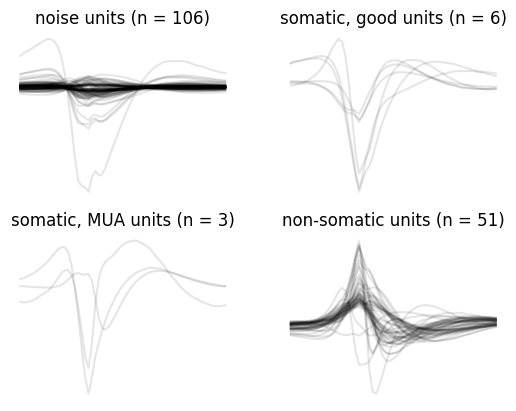

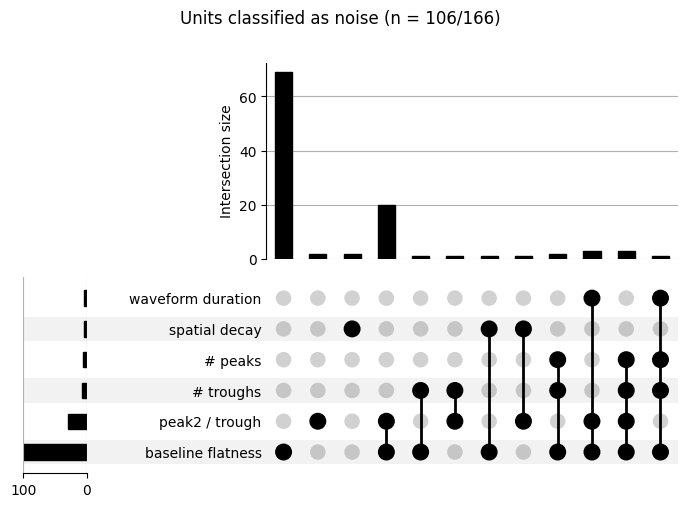

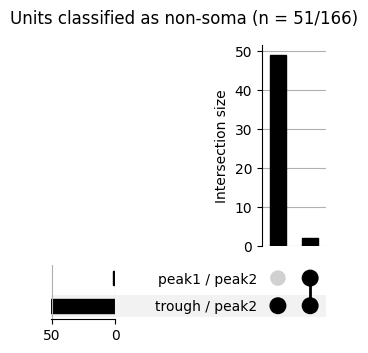

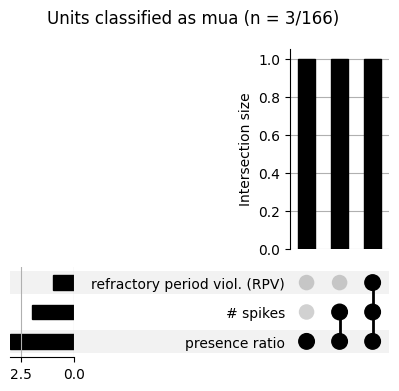

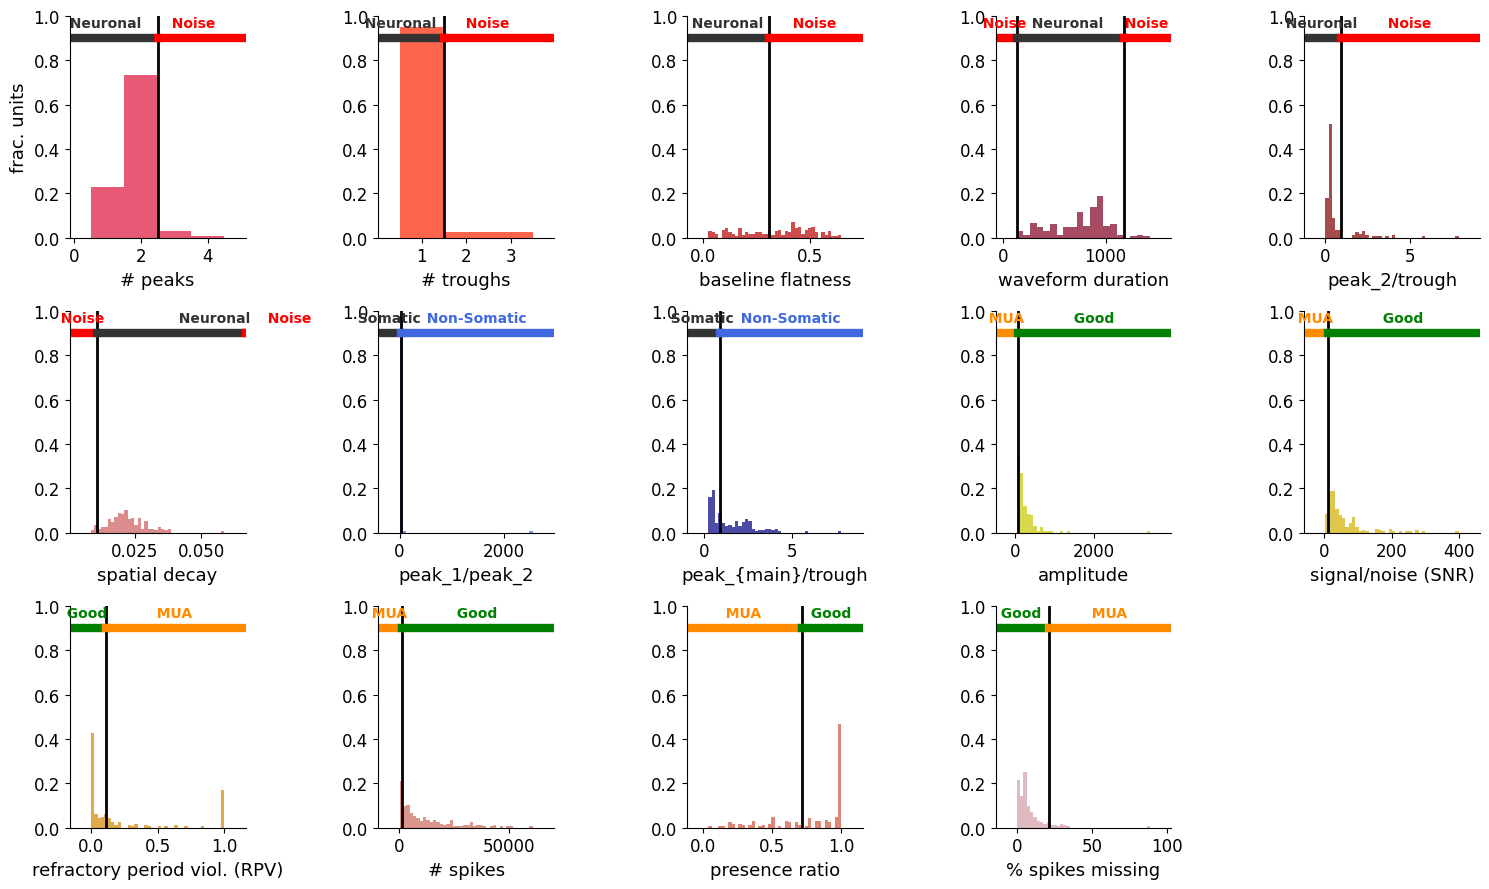


Saving results...
📁 Saving TSV files to Kilosort directory: Y:\GN26020\260307\spontaneous\session1\2026-03-07_12-02-05\kilosort4_motion_corrected
All expected metrics were successfully saved.


In [ ]:
(
    quality_metrics,
    param,
    unit_type,
    unit_type_string,
) = bc.run_bombcell(
    ks_dir, save_path, param,save_figures=True
)
# Use the output summary plots (below) to see if the 
# quality metric thresholds seem roughly OK for your 
# data (i.e. there isn't one threshold removing all 
# units or a threshold may below that removes none)
# more details on these output plots in the wiki:
# https://github.com/Julie-Fabre/bombcell/wiki/Summary-output-plots

##### How to access bombcell's saved quality metrics
Looking at all quality metric values per unit: 

In [ ]:
# quality metric values
quality_metrics_table = pd.DataFrame(quality_metrics)
quality_metrics_table.insert(0, 'Bombcell_unit_type', unit_type_string)
quality_metrics_table 

In [ ]:
# boolean table, if quality metrics pass threshold given parameters
boolean_quality_metrics_table = bc.make_qm_table(
    quality_metrics, param, unit_type_string
)
boolean_quality_metrics_table

Example: get all quality metrics for unit 12

In [12]:
u = 12

units = quality_metrics_table.phy_clusterID
quality_metrics_table.loc[units == u, :]

,Bombcell_unit_type,phy_clusterID,nSpikes,nPeaks,nTroughs,waveformDuration_peakTrough,spatialDecaySlope,waveformBaselineFlatness,scndPeakToTroughRatio,mainPeakToTroughRatio,...,maxDriftEstimate,cumDriftEstimate,rawAmplitude,signalToNoiseRatio,isolationDistance,Lratio,silhouetteScore,useTheseTimesStart,useTheseTimesStop,maxChannels
12,MUA,12,1085.0,2.0,1.0,800.0,0.01994,0.217775,0.291634,0.291634,...,1248.570557,21007.922241,19.41162,34.915456,NaN,NaN,NaN,0.0074,4265.891433,309


#### Look at your data and bombcell's metrics in the minimal GUI

In [ ]:
# Launch minimal GUI.
# Ideally, take a look at your units for a few datasets so you can get an idea of which 
# parameters will work best for your purposes. 
gui = bc.unit_quality_gui(
    ks_dir=ks_dir,
    quality_metrics=quality_metrics,
    unit_types=unit_type,
    param=param,
    save_path=save_path,
)

In [10]:
# Compare manual vs BombCell classifications (only requires save_path)
bc.compare_manual_vs_bombcell(save_path)

📊 Comparing manual vs BombCell classifications from: Y:\GN26020\260307\spontaneous\session1\2026-03-07_12-02-05\kilosort4_motion_corrected\bombcell
✅ Loaded BombCell results: 166 units
📂 Found manual classifications for 157 units
❌ BombCell unit types file not found: Y:\GN26020\260307\spontaneous\session1\2026-03-07_12-02-05\kilosort4_motion_corrected\bombcell\cluster_bc_unitType.tsv
📊 Classification Concordance Analysis
Total classified units: 157
Concordant classifications: 125
Overall concordance: 79.6%

Confusion Matrix (rows=BombCell, columns=Manual):
manual_type_name               Good  MUA  Noise  Non-somatic  All
Bombcell_unit_type_normalized                                    
Good                              6    0      0            0    6
MUA                               0    0      1            0    1
Noise                             0    4     80           15   99
Non-somatic                       0    0     12           39   51
All                               6    4 

#### Fine-tune quality metric thresholds 
Based on bombcell's global output plots, looking through the GUI, your knowledge of neurons in your brain region and bombcell's suggestions above, you can adjust any of bombcell's quality metric thresholds and which quality metrics are computed.
For instance, if you are recording in the cerebellum and want to keep complex spikes, you might want to tweak waveform paramaters like max number of peaks and troughs to ensure you aren't classifying these units as noise. 

In [11]:
# Example: how to tweak a classification threshold and replot the summary plots 

# load previously computed quality metrics
param, quality_metrics, fractions_RPVs_all_taur = bc.load_bc_results(save_path)
# change parameter of interest 
param["maxNPeaks"] = 3 # for instance, it you more atypical waveform shapes in your region of interest
# get quality unit types
unit_type, unit_type_string = bc.qm.get_quality_unit_type(
        param, quality_metrics
    ) 
# load ephys data
(
    spike_times_samples,
    spike_clusters, # actually spike_templates, but they're the same in bombcell
    template_waveforms,
    template_amplitudes,
    pc_features,
    pc_features_idx,
    channel_positions,
) = bc.load_ephys_data(ks_dir)
# replot global output plots
bc.plot_summary_data(quality_metrics, template_waveforms, unit_type, unit_type_string, param)


KeyError: 'unique_templates'

# Section 2: Ephys Properties & Cell Classification

In [17]:
# Use the real dataset for ephys properties demonstration
ks_dir = "toy_data"
save_path = Path(ks_dir) / "bombcell"

print(f"Using kilosort directory: {ks_dir}")

Using kilosort directory: toy_data


In [ ]:
# Compute ephys properties for cell type classification
ephys_param = bc.get_ephys_parameters(ks_dir)

# Compute all ephys properties - now defaults to ks_dir/bombcell
ephys_properties, ephys_param = bc.run_all_ephys_properties(ks_dir, ephys_param, save_path=save_path)

In [ ]:
# Cell type classification with automatic plot generation
# Specify brain region: 'cortex' or 'striatum'
brain_region = 'striatum'  # Change this to 'cortex' for cortical data. Striatum and cortex are the only two options for now. 

print(f"Classifying {brain_region} neurons...")
cell_types = bc.classify_and_plot_brain_region(ephys_properties, ephys_param, brain_region)

In [ ]:
# Show classification results
if cell_types is not None:
    # Create combined results table
    ephys_df = pd.DataFrame(ephys_properties)
    ephys_properties_table = ephys_df.copy()
    ephys_properties_table['cell_type'] = cell_types
   
    print(ephys_properties_table)